In [4]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install xgboost


  Using cached xgboost-3.0.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.0.0-py3-none-macosx_12_0_arm64.whl (2.0 MB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 20.3 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 17.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 17.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
import xarray as xr
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 数据导入：加载 NetCDF 文件
file_path = "preprocessed_merged_dataset.nc"  # 修改为你的文件路径
dataset = xr.open_dataset(file_path)

# 定义目标区域的经纬度范围（49.4~58.9 纬度，352.5~358.75 经度）
lat_min, lat_max = 49.4, 58.9
lon_min, lon_max = 352.5, 358.75  # 转换为0~360坐标系

# 从原始数据集中选择目标区域的数据
lat_indices = (dataset.lat >= lat_min) & (dataset.lat <= lat_max)
lon_indices = (dataset.lon >= lon_min) & (dataset.lon <= lon_max)

# 提取目标区域的数据：TREFHT 和其他特征（如 TREFMXAV_U, FLNS 等）
selected_data = dataset[['TREFHT', 'TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT']].isel(lat=lat_indices, lon=lon_indices)

# 将 xarray 数据转换为 pandas DataFrame
df_sel = selected_data.to_dataframe().reset_index()

# 将时间列转化为 datetime 类型
df_sel['time'] = pd.to_datetime(df_sel['time'])

# 划分训练集和测试集（使用时间切分：2025年1月1日之前为训练集，之后为测试集）
train_df = df_sel[df_sel['time'] < '2025-01-01']
test_df = df_sel[df_sel['time'] >= '2025-01-01']

print(f"✅ Train samples: {len(train_df)}")
print(f"✅ Test samples: {len(test_df)}")

# 选择特征和目标变量
features = ['TREFMXAV_U', 'FLNS', 'FSNS', 'PRECT', 'PRSN', 'QBOT', 'UBOT', 'VBOT']
target = 'TREFHT'

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 创建并训练 XGBoost 模型
best_xgb = XGBRegressor(
    subsample=0.6,
    reg_lambda=5,
    reg_alpha=0.1,
    n_estimators=1500,
    min_child_weight=10,
    max_depth=8,
    learning_rate=0.01,
    gamma=0.1,
    colsample_bytree=1.0,
    objective='reg:squarederror',
    random_state=42
)

best_xgb.fit(X_train, y_train)

# 预测
y_pred_optimized = best_xgb.predict(X_test)

# 计算预测样本数量
N = len(y_pred_optimized)
print(f"✅ Predicted samples: {N}")

# 计算从 2025-01-01 到 2080-12-12 的总天数
start_date = pd.to_datetime("2025-01-01")
end_date = pd.to_datetime("2080-12-12")
total_days = (end_date - start_date).days + 1  # 包括起始日期

print(f"✅ Total days in the prediction range: {total_days}")

# 确保预测样本数与时间范围一致
N = min(len(y_pred_optimized), total_days)  # 防止样本数超过时间范围

# 构造时间序列（2025-01-01 到 2080-12-12）
time = pd.date_range(start=start_date, periods=N, freq="D")

# 经纬度
lat = np.linspace(lat_min, lat_max, len(df_sel['lat'].unique()))  # 根据选定的纬度范围生成纬度值
lon = np.linspace(lon_min, lon_max, len(df_sel['lon'].unique()))  # 根据选定的经度范围生成经度值

# 确保预测结果的长度符合时间、纬度和经度网格
pred_data = y_pred_optimized[:N]

# 计算每个时间步的纬度和经度点数
num_lat = len(lat)
num_lon = len(lon)

# 检查预测输出是否符合要求
# 计算每个时间步预测的纬度 × 经度点数
expected_samples_per_time_step = num_lat * num_lon

# 如果预测的样本数是 20435，而你期望的是 N * num_lat * num_lon 的样子，计算应该进行什么调整
# 假设每个时间点的预测结果应该是纬度 * 经度的预测数据
N = len(y_pred_optimized) // expected_samples_per_time_step  # 确保预测样本数是合理的时间步数

print(f"✅ Predicted samples per time step: {expected_samples_per_time_step}")
print(f"✅ Number of time steps: {N}")

# 将预测结果 reshape 成 (时间, 纬度, 经度)
pred_data_reshaped = y_pred_optimized.reshape((N, num_lat, num_lon))

# 构造 Dataset
ds_fixed = xr.Dataset(
    {
        "predicted_value": (("time", "lat", "lon"), pred_data_reshaped)
    },
    coords={
        "time": time[:N],  # 确保时间序列与样本数匹配
        "lat": lat,
        "lon": lon
    }
)

# 保存为 NetCDF 文件
ds_fixed.to_netcdf("xgboost_predictions_fixed.nc")

print("✅ 修复完成，已保存为 xgboost_predictions_fixed.nc")


✅ Train samples: 416340
✅ Test samples: 1226100
✅ Predicted samples: 1226100
✅ Total days in the prediction range: 20435
✅ Predicted samples per time step: 60
✅ Number of time steps: 20435
✅ 修复完成，已保存为 xgboost_predictions_fixed.nc


In [ ]:
Prediction results for all latitude and longitude points in the entire area

✅ Optimized MAE: 0.42 °C
✅ Optimized RMSE: 0.56 °C


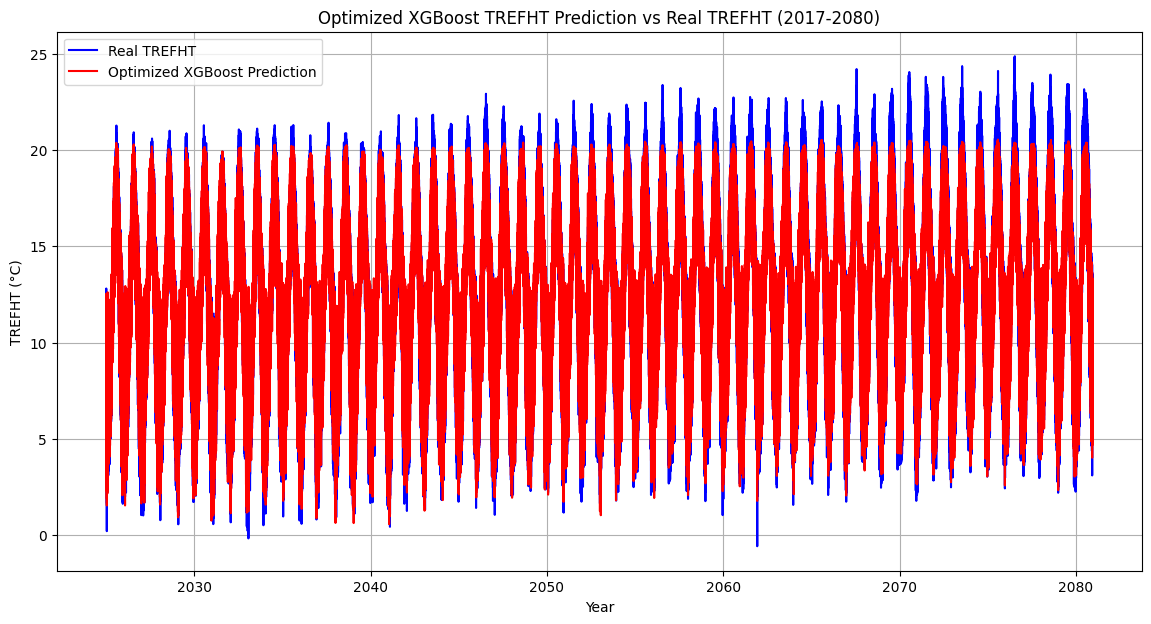

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 假设已经有 y_test 和 y_pred_optimized 作为模型的预测结果和真实值

# 计算 MAE（平均绝对误差）和 RMSE（均方根误差）
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))

# 输出 MAE 和 RMSE
print(f"✅ Optimized MAE: {mae_optimized:.2f} °C")
print(f"✅ Optimized RMSE: {rmse_optimized:.2f} °C")

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(14, 7))
plt.plot(test_df['time'], y_test, label='Real TREFHT', color='blue')  # 真实值
plt.plot(test_df['time'], y_pred_optimized, label='Optimized XGBoost Prediction', color='red')  # 预测值
plt.title('Optimized XGBoost TREFHT Prediction vs Real TREFHT (2017-2080)')
plt.xlabel('Year')
plt.ylabel('TREFHT (°C)')
plt.legend()
plt.grid(True)
plt.show()


Thermal map of predicted temperature in the geographical area on January 1, 2025

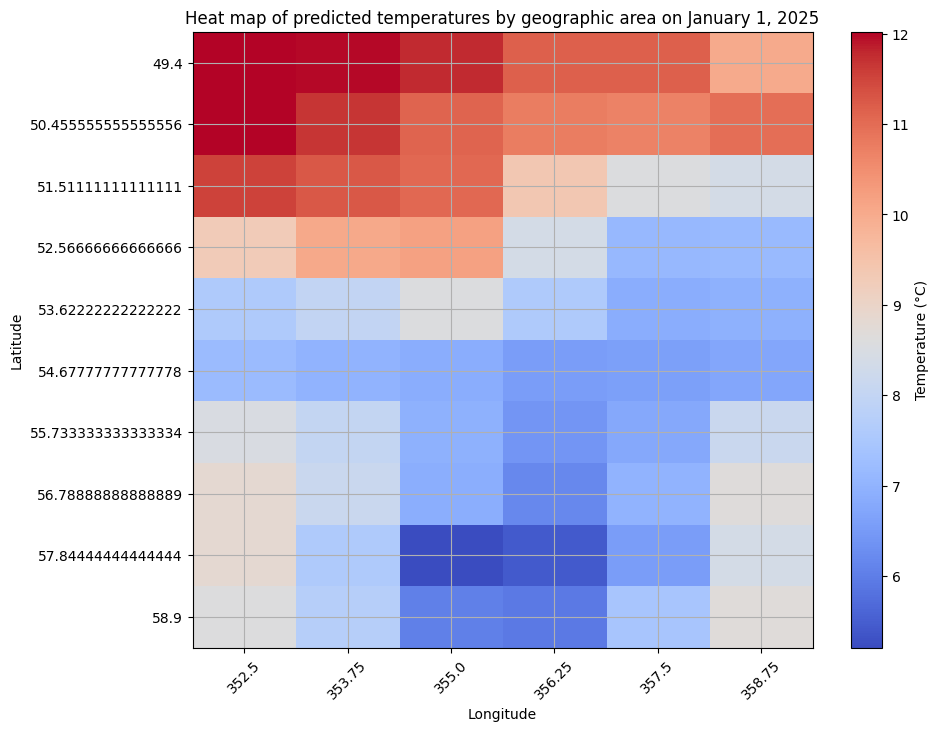

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# 假设你已经有了 pred_data_reshaped (时间, 纬度, 经度)

# 获取一个特定时间点的预测结果
time_index = 0  # 选择第一个时间点作为示例
pred_at_time = pred_data_reshaped[time_index, :, :]  # 该时间点的所有经纬度预测数据

# 绘制该时间点的热图
plt.figure(figsize=(10, 8))
plt.imshow(pred_at_time, cmap='coolwarm', interpolation='nearest', aspect='auto')
plt.title(f"Heat map of predicted temperatures by geographic area on January 1, 2025")
plt.colorbar(label='Temperature (°C)')  # 色标表示温度
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xticks(np.arange(len(lon)), lon, rotation=45)
plt.yticks(np.arange(len(lat)), lat)
plt.grid(True)
plt.show()


Each pixel in the heat map represents the predicted temperature at that latitude and longitude point, and the entire heat map shows the predicted temperature of all latitude and longitude points in the range of 49.4 to 58.9 latitude and 352.5 to 358.75 longitude on January 1, 2025.